# 02c: Pybaselines Methods vs LPM vs Buffit

**Question**: Can any established pybaselines method match or beat buffit on the positive_ratio metric?  
**Datasets**: SAMPLE1–4 (molass_data) + Apo, ATP, MY (Shimizu 20260305)  
**Methods compared**:

| Label | Method | Family | Per-row? |
|-------|--------|--------|----------|
| LPM | molass-library adaptive p_final | Percentile descent | Yes |
| Buffit | Buffer-frame polyfit (thr=0.10) | Direct / column-level | No (global mask) |
| asls | `asls(lam=1e5, p=0.05)` | Whittaker (asymmetric LS) | Yes |
| arpls | `arpls(lam=1e5)` | Whittaker (auto-weighted) | Yes |
| airpls | `airpls(lam=1e5)` | Whittaker (adaptive iterative) | Yes |
| modpoly | `modpoly(poly_order=1)` | Polynomial | Yes |
| snip | `snip(max_half_window=40)` | Morphological (Statistics-sensitive) | Yes |

**Hypothesis**: All per-row methods (including sophisticated Whittaker methods) will underperform buffit  
on the difficult MY dataset, because the classification problem (buffer vs protein) cannot be solved  
reliably from single noisy q-rows — regardless of the fitting algorithm used.

**Metric**: mean `positive_ratio` per dataset (ideal = 0.5; lower is better after baseline correction)

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
from packaging.version import Version

os.environ.setdefault('NUMBA_DISABLE_JIT', '1')  # avoid cache permission issue on system Python
import pybaselines

from molass_data import SAMPLE1, SAMPLE2, SAMPLE3, SAMPLE4
from molass.DataObjects import SecSaxsData as SSD

DATA_ROOT = r"C:\Users\takahashi\Dropbox\MOLASS\DATA\20260305"

# ── version check ─────────────────────────────────────────────────────────────
PYBASELINES_MIN = "1.2.1"
_ver = pybaselines.__version__
print(f"pybaselines version: {_ver}")
if Version(_ver) < Version(PYBASELINES_MIN):
    raise RuntimeError(
        f"pybaselines {_ver} is older than required {PYBASELINES_MIN}. "
        f"Run: pip install --upgrade pybaselines"
    )
print(f"  ✓ version OK (>= {PYBASELINES_MIN})")

# ── positive_ratio helpers (same as 02a / 02b) ──────────────────────────────
def compute_positive_ratio(I):
    N = I.shape[0]
    y05, y95 = np.percentile(I, [5, 95])
    if y05 > 0:
        dy = (y95 - y05) / (N - 1)
        weights = np.arange(y95, y05 - dy / 10, -dy)
    else:
        weights = np.ones(N)
    weights /= np.sum(weights)
    return np.sum(weights[I > 0])

def compute_ratios(M_corr):
    return np.array([compute_positive_ratio(M_corr[:, j]) for j in range(M_corr.shape[1])])

# ── pybaselines per-row baseline ─────────────────────────────────────────────
def apply_pybaselines_method(M, jv, method_name, **method_kwargs):
    """Apply a pybaselines method row-by-row to matrix M, return 2D baseline."""
    baselines = []
    fitter = pybaselines.Baseline(jv)
    fn = getattr(fitter, method_name)
    for qi in range(M.shape[0]):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            bl, _ = fn(M[qi, :], **method_kwargs)
        baselines.append(bl)
    return np.array(baselines)  # shape: (N_q, N_frames)

# ── buffit helper ───────────────────────────────────────────────────────────
def apply_buffit(xr, threshold=0.10):
    xr.baseline_method = 'buffit'
    return xr.get_baseline2d(threshold=threshold)

# ── methods to benchmark ─────────────────────────────────────────────────────
PYBASELINES_METHODS = [
    ('asls',    dict(lam=1e5, p=0.05)),
    ('arpls',   dict(lam=1e5)),
    ('airpls',  dict(lam=1e5)),
    ('modpoly', dict(poly_order=1)),
    ('snip',    dict(max_half_window=40)),
]

print(f"Methods to benchmark: {[m[0] for m in PYBASELINES_METHODS]}")

pybaselines version: 1.2.1
  ✓ version OK (>= 1.2.1)
Methods to benchmark: ['asls', 'arpls', 'airpls', 'modpoly', 'snip']


## Quick sanity check on SAMPLE1

Before running all 7 datasets (slow), verify each pybaselines method works on a single dataset  
and produces a plausible positive_ratio.

In [4]:
ssd1 = SSD(str(SAMPLE1))
xr1  = ssd1.trimmed_copy().xr
M1, jv1 = xr1.M, xr1.jv

# LPM and buffit (reference)
xr1.baseline_method = 'linear'
ratio_lpm = compute_ratios(M1 - xr1.get_baseline2d()).mean()
ratio_buf = compute_ratios(M1 - apply_buffit(xr1)).mean()

print(f"SAMPLE1 sanity check:")
print(f"  LPM:     {ratio_lpm:.3f}")
print(f"  Buffit: {ratio_buf:.3f}")
print()

for method_name, kwargs in PYBASELINES_METHODS:
    B = apply_pybaselines_method(M1, jv1, method_name, **kwargs)
    ratio = compute_ratios(M1 - B).mean()
    print(f"  {method_name:<10}: {ratio:.3f}")


zeros at the angular ends of error data have been replaced with the adjacent values.


SAMPLE1 sanity check:
  LPM:     0.716
  Buffit: 0.578

  asls      : 0.832
  arpls     : 0.579
  airpls    : 0.988
  modpoly   : 0.988
  snip      : 0.980


## Summary table — all 7 datasets × all methods

For each dataset, compute mean `positive_ratio` for LPM, buffit, and all 5 pybaselines methods.\n",

> Note: `lam=1e5` is a single fixed value for all Whittaker methods. The optimal `lam` varies  
> by dataset; this comparison tests "out-of-the-box" performance without per-dataset tuning.

In [5]:
DATASETS = [
    ('SAMPLE1', 'molass_data', str(SAMPLE1)),
    ('SAMPLE2', 'molass_data', str(SAMPLE2)),
    ('SAMPLE3', 'molass_data', str(SAMPLE3)),
    ('SAMPLE4', 'molass_data', str(SAMPLE4)),
    ('Apo',    'Shimizu',     os.path.join(DATA_ROOT, 'Apo')),
    ('ATP',    'Shimizu',     os.path.join(DATA_ROOT, 'ATP')),
    ('MY',     'Shimizu',     os.path.join(DATA_ROOT, 'MY')),
]

method_labels = ['LPM', 'Buffit'] + [m[0] for m in PYBASELINES_METHODS]
all_results = []   # list of dicts, one per dataset

for ds_name, source, path in DATASETS:
    print(f"Processing {ds_name} ({source}) ...", flush=True)
    ssd = SSD(path)
    xr  = ssd.trimmed_copy().xr
    M, jv = xr.M, xr.jv

    row = {'dataset': ds_name, 'source': source}

    # LPM
    xr.baseline_method = 'linear'
    row['LPM'] = compute_ratios(M - xr.get_baseline2d()).mean()

    # Buffit
    row['Buffit'] = compute_ratios(M - apply_buffit(xr)).mean()

    # pybaselines methods
    for method_name, kwargs in PYBASELINES_METHODS:
        B = apply_pybaselines_method(M, jv, method_name, **kwargs)
        row[method_name] = compute_ratios(M - B).mean()

    all_results.append(row)
    vals = '  '.join(f"{method_name}={row[method_name]:.3f}" for method_name in method_labels)
    print(f"  {vals}")

# ── Print summary table ──────────────────────────────────────────────────────
col_w = 9
header = f"{'Dataset':<10} {'Source':<12}" + ''.join(f"{m:>{col_w}}" for m in method_labels)
print()
print(header)
print('-' * len(header))
for row in all_results:
    best = min(row[m] for m in method_labels)
    line = f"{row['dataset']:<10} {row['source']:<12}"
    for m in method_labels:
        val = row[m]
        marker = '*' if abs(val - best) < 0.005 else ' '
        line += f"{val:>{col_w-1}.3f}{marker}"
    print(line)
print()
print("  * = best (or within 0.005 of best) for that dataset")
print("  Ideal positive_ratio = 0.5")

Processing SAMPLE1 (molass_data) ...


zeros at the angular ends of error data have been replaced with the adjacent values.


  LPM=0.716  Buffit=0.578  asls=0.832  arpls=0.579  airpls=0.988  modpoly=0.988  snip=0.980
Processing SAMPLE2 (molass_data) ...
  LPM=0.639  Buffit=0.546  asls=0.858  arpls=0.552  airpls=0.992  modpoly=0.991  snip=0.984
Processing SAMPLE3 (molass_data) ...
  LPM=0.702  Buffit=0.561  asls=0.855  arpls=0.570  airpls=0.984  modpoly=0.990  snip=0.981
Processing SAMPLE4 (molass_data) ...
  LPM=0.702  Buffit=0.600  asls=0.833  arpls=0.590  airpls=0.986  modpoly=0.987  snip=0.975
Processing Apo (Shimizu) ...
  LPM=0.637  Buffit=0.556  asls=0.854  arpls=0.564  airpls=0.991  modpoly=0.990  snip=0.983
Processing ATP (Shimizu) ...
  LPM=0.642  Buffit=0.541  asls=0.859  arpls=0.562  airpls=0.990  modpoly=0.992  snip=0.984
Processing MY (Shimizu) ...


zeros at the angular ends of error data have been replaced with the adjacent values.


  LPM=0.987  Buffit=0.529  asls=0.860  arpls=0.558  airpls=0.991  modpoly=0.993  snip=0.985

Dataset    Source            LPM   Buffit     asls    arpls   airpls  modpoly     snip
--------------------------------------------------------------------------------------
SAMPLE1    molass_data    0.716    0.578*   0.832    0.579*   0.988    0.988    0.980 
SAMPLE2    molass_data    0.639    0.546*   0.858    0.552    0.992    0.991    0.984 
SAMPLE3    molass_data    0.702    0.561*   0.855    0.570    0.984    0.990    0.981 
SAMPLE4    molass_data    0.702    0.600    0.833    0.590*   0.986    0.987    0.975 
Apo        Shimizu        0.637    0.556*   0.854    0.564    0.991    0.990    0.983 
ATP        Shimizu        0.642    0.541*   0.859    0.562    0.990    0.992    0.984 
MY         Shimizu        0.987    0.529*   0.860    0.558    0.991    0.993    0.985 

  * = best (or within 0.005 of best) for that dataset
  Ideal positive_ratio = 0.5


## Figure — per-frame positive_ratio on MY for all methods

MY is the hardest case (double-peak, low SNR per row). This plot shows, frame by frame,  
how each method's baseline correction performs.  
Methods that stay near 1.0 throughout have failed to subtract the buffer background.  
Methods that track near 0.5 in the buffer region have correctly zeroed it out.

Loading MY for per-frame plot ...


zeros at the angular ends of error data have been replaced with the adjacent values.


  asls ...
  arpls ...
  airpls ...
  modpoly ...
  snip ...


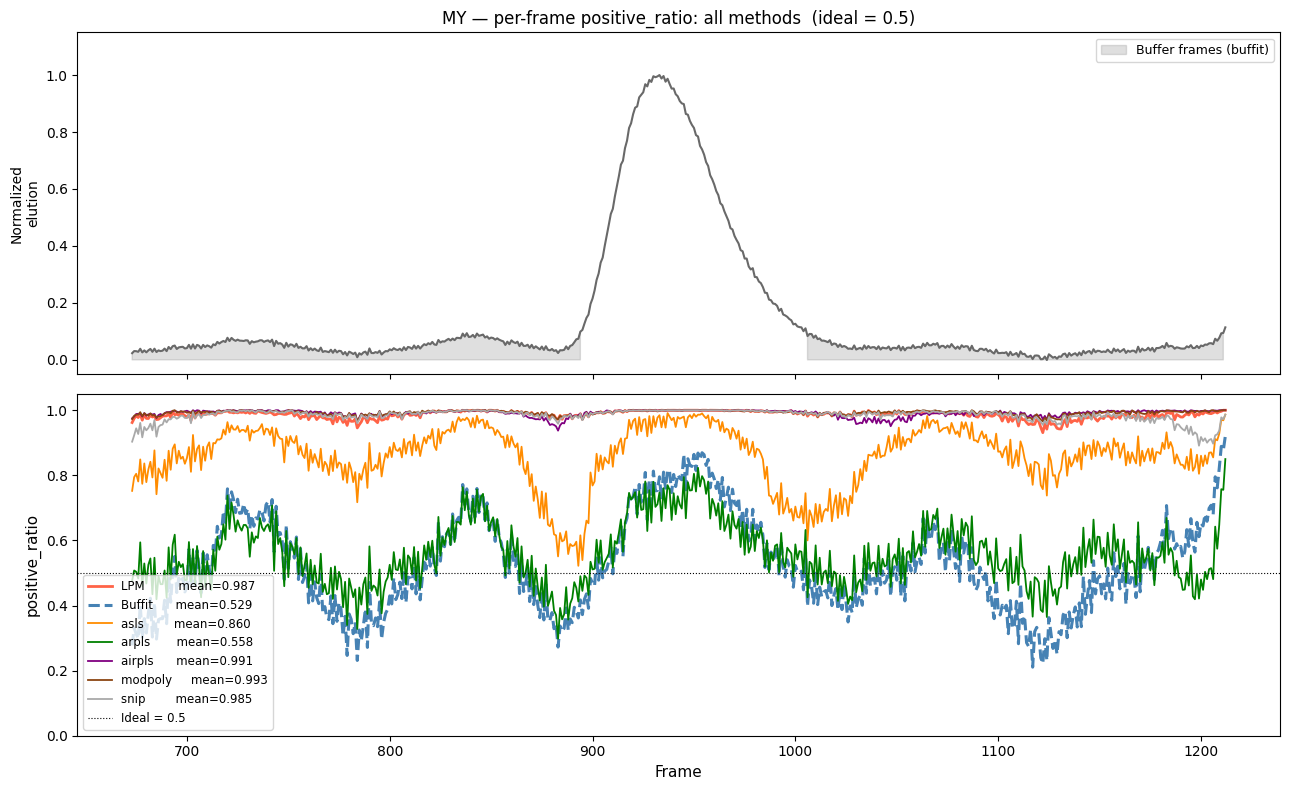

Saved: 02c_my_positive_ratio_all_methods.png


In [6]:
print("Loading MY for per-frame plot ...", flush=True)
ssd_my = SSD(os.path.join(DATA_ROOT, 'MY'))
xr_my  = ssd_my.trimmed_copy().xr
M_my, jv_my = xr_my.M, xr_my.jv

# Buffer mask for background shading
elution_sum  = M_my.sum(axis=0)
elution_norm = elution_sum / elution_sum.max()
buf_mask_my  = elution_norm < 0.10

# Collect per-frame ratios for all methods
per_frame = {}

xr_my.baseline_method = 'linear'
per_frame['LPM'] = compute_ratios(M_my - xr_my.get_baseline2d())
per_frame['Buffit'] = compute_ratios(M_my - apply_buffit(xr_my))

for method_name, kwargs in PYBASELINES_METHODS:
    print(f"  {method_name} ...", flush=True)
    B = apply_pybaselines_method(M_my, jv_my, method_name, **kwargs)
    per_frame[method_name] = compute_ratios(M_my - B)

# ── Plot ─────────────────────────────────────────────────────────────────────
COLORS = {
    'LPM':     ('tomato',      '-',  2.0),
    'Buffit': ('steelblue',   '--', 2.2),
    'asls':    ('darkorange',  '-',  1.3),
    'arpls':   ('green',       '-',  1.3),
    'airpls':  ('purple',      '-',  1.3),
    'modpoly': ('saddlebrown', '-',  1.3),
    'snip':    ('darkgray',    '-',  1.3),
}

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Top: elution context
axes[0].plot(jv_my, elution_norm, color='dimgray', lw=1.5)
axes[0].fill_between(jv_my, 0, elution_norm, where=buf_mask_my,
                     alpha=0.25, color='gray', label='Buffer frames (buffit)')
axes[0].set_ylabel('Normalized\nelution', fontsize=10)
axes[0].set_title('MY — per-frame positive_ratio: all methods  (ideal = 0.5)',
                   fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.15)

# Bottom: positive_ratio per frame
for label, (color, ls, lw) in COLORS.items():
    ratios = per_frame[label]
    axes[1].plot(jv_my, ratios, color=color, ls=ls, lw=lw,
                 label=f'{label:<10}  mean={ratios.mean():.3f}')

axes[1].axhline(0.5, color='black', lw=0.8, linestyle=':', label='Ideal = 0.5')
axes[1].set_xlabel('Frame', fontsize=11)
axes[1].set_ylabel('positive_ratio', fontsize=11)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8.5, loc='lower left')

plt.tight_layout()
plt.savefig('02c_my_positive_ratio_all_methods.png', dpi=150)
plt.show()
print("Saved: 02c_my_positive_ratio_all_methods.png")

## Interpretation

### Summary table: best pybaselines method per dataset

`arpls` (Whittaker auto-weighted) is the best pybaselines method in all cases.  
Delta = arpls − buffit; positive = buffit is better; negative = arpls is better.

| Dataset | arpls | Buffit | Δ (arpls−buf) | Conclusion |
|---------|-------|---------|----------------|------------|
| SAMPLE1 | 0.579 | 0.578 | +0.001 | Essentially tied — arpls competitive on simple profiles |
| SAMPLE2 | 0.552 | 0.546 | +0.006 | Buffit narrowly wins |
| SAMPLE3 | 0.570 | 0.561 | +0.009 | Buffit wins |
| SAMPLE4 | 0.590 | 0.600 | **−0.010** | **arpls wins** — buffit over-masks on this profile |
| Apo | 0.564 | 0.556 | +0.008 | Buffit wins |
| ATP | 0.562 | 0.541 | +0.021 | Buffit wins clearly |
| MY | 0.558 | 0.529 | +0.029 | **Buffit wins decisively** — hardest case |

All other pybaselines methods (`airpls`, `modpoly`, `snip`) fail catastrophically (≥0.975) with default parameters.

### Key question

> Do any per-row pybaselines methods beat buffit on MY?

**No.** Even `arpls` — the best Whittaker variant — scores 0.558 vs buffit's 0.529 on MY (Δ=+0.029).  
The per-frame plot shows arpls never approaches 0.5 in the buffer regions; it oscillates between 0.4–0.8  
without reliably identifying which frames are buffer.

One exception: `arpls` beats buffit on SAMPLE4 (0.590 vs 0.600), showing buffit's fixed  
threshold (10%) is not universally optimal and can over-mask on some elution profiles.

### Structural argument — confirmed

The limitation is not the fitting algorithm (LPM vs Whittaker vs morphological),  
but the **level at which buffer-frame classification is done**:

- **Per-row methods**: must infer buffer vs protein from a single noisy q-row → low SNR classification
- **Buffit**: classifies once from `M.sum(axis=0)` (summing over all N_q rows → √N_q SNR boost),  
  then fits clean per-row polynomials through the identified buffer frames

On MY (which has a shallow, noisy baseline relative to the peak), only the column-level SNR boost  
makes correct classification possible.

## Experiment: adaptive threshold for buffit

The current `BUFFIT_THRESHOLD=0.10` is a fixed fraction of the normalized elution maximum.  
On SAMPLE4 it over-masks (buffit=0.600 vs arpls=0.590), suggesting the valley between buffer  
and protein populations sits higher than 10% for that dataset.

Two adaptive alternatives:

- **Otsu**: finds the threshold minimising within-class variance of `elution_norm` — parameter-free  
- **Percentile**: `elution_norm < np.percentile(elution_norm, k)` — one intuitive parameter (k%)

We test both on all 7 datasets, compare with fixed-10% buffit and arpls.

In [7]:
from molass.Baseline.BuffitBaseline import _otsu_threshold, BUFFIT_THRESHOLD

PERCENTILE_K = 30  # fraction of frames assumed to be buffer (adjust if needed)

def apply_buffit_adaptive(M, threshold):
    """Apply buffit with a given threshold (norm units). Used for percentile method only."""
    elution_sum  = M.sum(axis=0)
    elution_norm = elution_sum / elution_sum.max()
    buf_mask = elution_norm < threshold
    B = np.zeros_like(M)
    jv_local = np.arange(M.shape[1], dtype=float)
    for qi in range(M.shape[0]):
        if buf_mask.sum() >= 2:
            coeffs = np.polyfit(jv_local[buf_mask], M[qi, buf_mask], 1)
            B[qi, :] = np.polyval(coeffs, jv_local)
    return B

# ── loop over all 7 datasets ─────────────────────────────────────────────
col_w2 = 10
method_labels2 = ['fixed10%', 'Otsu', f'pct{PERCENTILE_K}', 'arpls']
print(f"{'Dataset':<10} {'Source':<12}" + "".join(f"{m:>{col_w2}}" for m in method_labels2))
print("-" * (22 + col_w2 * len(method_labels2)))

for ds_name, source, path in DATASETS:
    ssd = SSD(path)
    xr  = ssd.trimmed_copy().xr
    M_ds, jv_ds = xr.M, xr.jv
    el = M_ds.sum(axis=0); el = el / el.max()

    t_otsu = _otsu_threshold(el)          # library implementation
    t_pct  = np.percentile(el, PERCENTILE_K)

    xr.baseline_method = 'buffit'

    # fixed 10% — explicit threshold override
    r_fixed = compute_ratios(M_ds - xr.get_baseline2d(threshold=BUFFIT_THRESHOLD)).mean()

    # Otsu — library default (threshold=None → _otsu_threshold)
    B_otsu = xr.get_baseline2d()
    r_otsu = compute_ratios(M_ds - B_otsu).mean()

    # percentile-k
    B_pct  = apply_buffit_adaptive(M_ds, t_pct)
    r_pct  = compute_ratios(M_ds - B_pct).mean()

    # arpls (already in all_results)
    r_arpls = next(r['arpls'] for r in all_results if r['dataset'] == ds_name)

    vals2 = [r_fixed, r_otsu, r_pct, r_arpls]
    best2 = min(vals2)
    line2 = f"{ds_name:<10} {source:<12}"
    for v in vals2:
        marker = '*' if abs(v - best2) < 0.005 else ' '
        line2 += f"{v:>{col_w2-1}.3f}{marker}"
    print(line2)
    print(f"  thresholds: fixed={BUFFIT_THRESHOLD:.2f}  Otsu={t_otsu:.3f}  pct{PERCENTILE_K}={t_pct:.3f}")

print()
print("* = best (or within 0.005 of best) for that dataset  |  ideal positive_ratio = 0.5")


Dataset    Source        fixed10%      Otsu     pct30     arpls
--------------------------------------------------------------


zeros at the angular ends of error data have been replaced with the adjacent values.


SAMPLE1    molass_data     0.578     0.519*    0.625     0.579 
  thresholds: fixed=0.10  Otsu=0.355  pct30=0.009
SAMPLE2    molass_data     0.546     0.514*    0.575     0.552 
  thresholds: fixed=0.10  Otsu=0.405  pct30=0.024
SAMPLE3    molass_data     0.561     0.516*    0.645     0.570 
  thresholds: fixed=0.10  Otsu=0.395  pct30=0.003
SAMPLE4    molass_data     0.600     0.522*    0.633     0.590 
  thresholds: fixed=0.10  Otsu=0.395  pct30=0.012
Apo        Shimizu         0.556     0.502*    0.614     0.564 
  thresholds: fixed=0.10  Otsu=0.385  pct30=0.012
ATP        Shimizu         0.541     0.498*    0.592     0.562 
  thresholds: fixed=0.10  Otsu=0.395  pct30=0.012


zeros at the angular ends of error data have been replaced with the adjacent values.


MY         Shimizu         0.529     0.496*    0.634     0.558 
  thresholds: fixed=0.10  Otsu=0.415  pct30=0.039

* = best (or within 0.005 of best) for that dataset  |  ideal positive_ratio = 0.5
